In [ ]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import utils
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from dataset import load_uci_dataset, encode_labels, get_holdout_dataloaders, get_preprocessor
from models import MLP
from losses import PolyLoss, CombinedCLoss
from engine import train_model, evaluate_model
from plot_utils import plot_training_history
from gdv_utils import calculate_gdv

print("=== 1. SETUP AMBIENTE E DOWNLOAD DATI ===")

config_init = utils.carica_configurazione("config.yaml")
dataset_id = config_init['dataset']['uci_id']
device = torch.device(config_init['training']['device'] if torch.cuda.is_available() else "cpu")
print(f"Dispositivo in uso: {device}")

# Caricamento Dati
X_raw, y_raw = load_uci_dataset(dataset_id)

# =================================================================
# --- 1. SANIFICAZIONE E INFERENZA DEI TIPI AVANZATA (BISTURI) ---
# Sostituiamo stringhe vuote o segnaposto con veri NaN matematici
X_raw = X_raw.replace(['?', 'NA', 'null', 'None', '', ' '], np.nan)

for col in X_raw.columns:
    # Se la colonna NON è già matematicamente un numero (quindi è testo, object, string, ecc.)
    if not pd.api.types.is_numeric_dtype(X_raw[col]):
        
        # 1. Contiamo quanti dati REALI (non nulli) ci sono in questa colonna
        valori_presenti = X_raw[col].notna().sum()
        
        if valori_presenti > 0:
            # 2. Proviamo a convertire in numero, cambiando la virgola in punto SOLO per questo test
            tentativo = pd.to_numeric(X_raw[col].astype(str).str.replace(',', '.'), errors='coerce')
            numeri_validi = tentativo.notna().sum()
            
            # 3. Se il 90% dei dati *presenti* si è rivelato essere un numero...
            if (numeri_validi / valori_presenti) > 0.90:
                # ...allora la colonna è matematicamente numerica! La salviamo.
                X_raw[col] = tentativo
# =================================================================

# --- 2. BLACKLIST DATA LEAKAGE ---
X_raw = X_raw.drop(columns=['result'], errors='ignore')

# --- 3. RIMOZIONE COLONNE ID E ALTA CARDINALITÀ ---
colonne_rimosse = []
for col in list(X_raw.columns):
    
    # Regola A: ID espliciti (tutti valori unici)
    if X_raw[col].nunique() == len(X_raw):
        
        # 1. Se è Testo (es. "Nome_Paziente", "Hash"), lo droppiamo subito
        if not pd.api.types.is_numeric_dtype(X_raw[col]):
            colonne_rimosse.append(col)
            X_raw = X_raw.drop(columns=[col])
            
        # 2. Se è un Intero (int), potrebbe essere una misura fisica (es. Pixel) o un ID (1,2,3...)
        elif pd.api.types.is_integer_dtype(X_raw[col]):
            # Gli ID veri sono quasi sempre sequenziali. Le misure fisiche no.
            if X_raw[col].is_monotonic_increasing or X_raw[col].is_monotonic_decreasing:
                colonne_rimosse.append(col)
                X_raw = X_raw.drop(columns=[col])
                
        # (I decimali continui - float - vengono ignorati e salvati automaticamente)
                
    # Regola B: Testo con alta cardinalità (>50% valori unici)
    elif not pd.api.types.is_numeric_dtype(X_raw[col]):
        if X_raw[col].nunique() > (len(X_raw) * 0.5):
            colonne_rimosse.append(col)
            X_raw = X_raw.drop(columns=[col])

if colonne_rimosse:
    print(f"[*] Attenzione: rimosse le seguenti colonne ID o ad alta cardinalità: {colonne_rimosse}")
# =================================================================

y_encoded, n_classes = encode_labels(y_raw)
in_dim = X_raw.shape[1]

print("Pulizia, codifica e calcolo GDV geometrico iniziale in corso...")

preprocessor = get_preprocessor(X_raw)
X_processed = preprocessor.fit_transform(X_raw)

# --- SICUREZZA PYTORCH: Conversione da Matrice Sparsa a Densa ---
if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()

# --- Calcolo la dimensione reale dopo il One-Hot Encoding ---
in_dim_processed = X_processed.shape[1]

# Conversione in tensori
X_tensor = torch.tensor(X_processed, dtype=torch.float32)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)

GDV_INIZIALE = calculate_gdv(X_tensor, y_tensor)

print(f"\n--- Dimensioni Rilevate dal Dataset (UCI {dataset_id}) ---")
print(f"Features Originarie: {in_dim}")
print(f"Features Post-Processing (Input Rete): {in_dim_processed}")
print(f"Classi (Output):  {n_classes}")
print(f"GDV Dati Grezzi (Spazio Input):  {GDV_INIZIALE:.4f}")
print("===================================================")

=== 1. SETUP AMBIENTE E DOWNLOAD DATI ===
[*] Configurazione caricata da: config.yaml
Dispositivo in uso: cuda
Scaricamento del dataset UCI ID 222...
Pulizia, codifica e calcolo GDV geometrico iniziale in corso...

--- Dimensioni Rilevate dal Dataset (UCI 222) ---
Features Originarie: 16
Features Post-Processing (Input Rete): 47
Classi (Output):  2
GDV Dati Grezzi (Spazio Input):  -0.0205


In [2]:
print("=== 2. RICARICAMENTO CONFIGURAZIONE E DATALOADER ===")

config = utils.carica_configurazione("config.yaml")

# Imposta il seed per la riproducibilità degli split
random_state = config['dataset'].get('random_state', 42)
torch.manual_seed(random_state)

# --- CREAZIONE VELOCE DATALOADER ---
batch_size = config['dataset']['batch_size']
train_loader, val_loader, test_loader = get_holdout_dataloaders(
    X_raw, y_encoded, batch_size=batch_size, random_state=random_state
)

# --- IL VERO SALVAVITA: Leggiamo la dimensione dal Dataloader! ---
batch_x, _ = next(iter(train_loader))
in_dim_processed = batch_x.shape[1]
print(f"\n[*] Feature REALI in uscita dal preprocessing (Train Set): {in_dim_processed}")

# --- SETUP ARCHITETTURA DINAMICA ---
config_layers = config['model'].get('hidden_layers', "auto")

if config_layers == "auto":
    # Calcoliamo il numero totale di righe (campioni)
    num_samples = len(X_raw)
    
    # Passiamo anche num_samples alla funzione!
    hidden_layers = utils.get_auto_hidden_layers(in_dim_processed, n_classes, num_samples)
    print(f"Architettura Auto-Selezionata: {in_dim_processed} -> {hidden_layers} -> {n_classes} (su {num_samples} campioni)")
    # Sovrascrive la config in RAM per le celle di addestramento
    config['model']['hidden_layers'] = hidden_layers 
else:
    print(f"Architettura Forzata da YAML: {in_dim_processed} -> {config_layers} -> {n_classes}")

    
print(f"\nDataloader creati! (Batch size: {batch_size})")

# --- PESI DI CLASSE BILANCIATI (Hold-Out) ---
from sklearn.utils.class_weight import compute_class_weight
_y_train_ho = np.concatenate([lbl.numpy() for _, lbl in train_loader])
_cw = compute_class_weight('balanced', classes=np.arange(n_classes), y=_y_train_ho)
weights_holdout = torch.tensor(_cw, dtype=torch.float32).to(device)
print(f'[*] Pesi Hold-Out calcolati: {_cw.round(3)}')
print("Pronto per l'addestramento.")

=== 2. RICARICAMENTO CONFIGURAZIONE E DATALOADER ===
[*] Configurazione caricata da: config.yaml

[*] Feature REALI in uscita dal preprocessing (Train Set): 47
Architettura Auto-Selezionata: 47 -> [188, 94] -> 2 (su 45211 campioni)

Dataloader creati! (Batch size: 64)
Pronto per l'addestramento.


In [3]:
# === ESPERIMENTO 1: BASELINE (CROSS-ENTROPY) ===
print(f"\nAvvio Addestramento: Cross-Entropy su Dataset UCI ID {dataset_id} (Hold-Out)")

torch.manual_seed(config['dataset'].get('random_state', 42))

model_ce = MLP(
    input_size=in_dim_processed, 
    num_classes=n_classes,
    hidden_layers=config['model']['hidden_layers'],
    dropout_rate=config['model']['dropout_rate']
).to(device)

criterion_ce = nn.CrossEntropyLoss(weight=weights_holdout)
optimizer_ce = optim.Adam(model_ce.parameters(), lr=config['training']['learning_rate'])

gdv_layer = model_ce.get_layer_for_gdv(index=config['model']['gdv_layer_index'])

history_ce, best_epoch_ce = train_model(
    model=model_ce, criterion=criterion_ce, optimizer=optimizer_ce, 
    train_loader=train_loader, val_loader=val_loader, device=device,
    num_epochs=config['training']['epochs'], layer_for_gdv=gdv_layer
)

test_acc_ce = evaluate_model(model_ce, test_loader, device)
history_ce['test_acc'] = test_acc_ce
print(f"Accuratezza Test Finale: {test_acc_ce:.2f}%")

# MLOps: Salvataggio log e Grafici
utils.salva_storico_json(     
    history=history_ce,     
    nome_esperimento=f"HoldOut_CE_UCI_{dataset_id}",
    dataset_id=dataset_id
)


Avvio Addestramento: Cross-Entropy su Dataset UCI ID 222 (Hold-Out)
Epoca 01/500 | Train Loss: 0.2455 | Val Loss: 0.2321 | Val Acc: 89.95% | Val GDV: -0.2043
Epoca 05/500 | Train Loss: 0.1972 | Val Loss: 0.2132 | Val Acc: 90.51% | Val GDV: -0.1631
Epoca 10/500 | Train Loss: 0.1781 | Val Loss: 0.2224 | Val Acc: 90.24% | Val GDV: -0.1432
Epoca 15/500 | Train Loss: 0.1598 | Val Loss: 0.2340 | Val Acc: 89.68% | Val GDV: -0.1051
Epoca 20/500 | Train Loss: 0.1383 | Val Loss: 0.2506 | Val Acc: 89.67% | Val GDV: -0.0766
Epoca 25/500 | Train Loss: 0.1166 | Val Loss: 0.2845 | Val Acc: 89.19% | Val GDV: -0.0572
Epoca 30/500 | Train Loss: 0.0966 | Val Loss: 0.3319 | Val Acc: 89.15% | Val GDV: -0.0483
Epoca 35/500 | Train Loss: 0.0799 | Val Loss: 0.3775 | Val Acc: 89.19% | Val GDV: -0.0384
Epoca 40/500 | Train Loss: 0.0693 | Val Loss: 0.4311 | Val Acc: 89.02% | Val GDV: -0.0337
Epoca 45/500 | Train Loss: 0.0582 | Val Loss: 0.4630 | Val Acc: 88.76% | Val GDV: -0.0338
Epoca 50/500 | Train Loss: 0.05

'results\\222\\logs\\2026-05-18_14-00-53-HoldOut_CE_UCI_222.json'

In [4]:
# === ESPERIMENTO 2: POLYLOSS ===
print(f"\nAvvio Addestramento: PolyLoss su Dataset UCI ID {dataset_id} (Hold-Out)")

eps = config.get('loss_params', {}).get('polyloss', {}).get('epsilon', 2.0)
nome_poly_plot = f"PolyLoss (e={eps}) - UCI {dataset_id}"

torch.manual_seed(config['dataset'].get('random_state', 42))

# Inizializzazione modello
model_poly = MLP(
    input_size=in_dim_processed, 
    num_classes=n_classes,
    hidden_layers=config['model']['hidden_layers'],
    dropout_rate=config['model']['dropout_rate']
).to(device)

criterion_poly = PolyLoss(epsilon=eps, weight=weights_holdout)
optimizer_poly = optim.Adam(model_poly.parameters(), lr=config['training']['learning_rate'])

gdv_layer = model_poly.get_layer_for_gdv(index=config['model']['gdv_layer_index'])

history_poly, best_epoch_poly = train_model(
    model=model_poly, criterion=criterion_poly, optimizer=optimizer_poly, 
    train_loader=train_loader, val_loader=val_loader, device=device,
    num_epochs=config['training']['epochs'], layer_for_gdv=gdv_layer
)

test_acc_poly = evaluate_model(model_poly, test_loader, device)
history_poly['test_acc'] = test_acc_poly
print(f"Accuratezza Test Finale: {test_acc_poly:.2f}%")

# MLOps: Salvataggio log e Grafici
utils.salva_storico_json(     
    history=history_poly,     
    nome_esperimento=f"HoldOut_PolyLoss_UCI_{dataset_id}",
    dataset_id=dataset_id 
)


Avvio Addestramento: PolyLoss su Dataset UCI ID 222 (Hold-Out)
Epoca 01/500 | Train Loss: 0.5280 | Val Loss: 0.4956 | Val Acc: 89.96% | Val GDV: -0.2243
Epoca 05/500 | Train Loss: 0.4245 | Val Loss: 0.4592 | Val Acc: 90.42% | Val GDV: -0.2037
Epoca 10/500 | Train Loss: 0.3848 | Val Loss: 0.4728 | Val Acc: 90.02% | Val GDV: -0.1784
Epoca 15/500 | Train Loss: 0.3522 | Val Loss: 0.4929 | Val Acc: 89.99% | Val GDV: -0.1410
Epoca 20/500 | Train Loss: 0.3118 | Val Loss: 0.5061 | Val Acc: 90.15% | Val GDV: -0.1177
Epoca 25/500 | Train Loss: 0.2714 | Val Loss: 0.5556 | Val Acc: 89.62% | Val GDV: -0.0918
Epoca 30/500 | Train Loss: 0.2355 | Val Loss: 0.5921 | Val Acc: 89.86% | Val GDV: -0.0734
Epoca 35/500 | Train Loss: 0.2009 | Val Loss: 0.6501 | Val Acc: 89.49% | Val GDV: -0.0634
Epoca 40/500 | Train Loss: 0.1721 | Val Loss: 0.6894 | Val Acc: 89.16% | Val GDV: -0.0552
Epoca 45/500 | Train Loss: 0.1493 | Val Loss: 0.7556 | Val Acc: 89.37% | Val GDV: -0.0508
Epoca 50/500 | Train Loss: 0.1311 | 

'results\\222\\logs\\2026-05-18_14-10-59-HoldOut_PolyLoss_UCI_222.json'

In [ ]:
# === ESPERIMENTO 3: COMBINED C-LOSS ===
print(f"\nAvvio Addestramento: Combined C-Loss su Dataset UCI ID {dataset_id} (Hold-Out)")

sig = config.get('loss_params', {}).get('closs', {}).get('sigma', 0.5)
gam = config.get('loss_params', {}).get('closs', {}).get('gamma', 0.5)
nome_closs_plot = f"Combined C-Loss (s={sig} - UCI {dataset_id}"

torch.manual_seed(config['dataset'].get('random_state', 42))

# Inizializzazione modello
model_closs = MLP(
    input_size=in_dim_processed, 
    num_classes=n_classes,
    hidden_layers=config['model']['hidden_layers'],
    dropout_rate=config['model']['dropout_rate']
).to(device)

# Uso dei parametri dinamici estratti dal config
criterion_closs = CombinedCLoss(sigma=sig, weight=weights_holdout)
optimizer_closs = optim.Adam(model_closs.parameters(), lr=config['training']['learning_rate'])

gdv_layer = model_closs.get_layer_for_gdv(index=config['model']['gdv_layer_index'])

history_closs, best_epoch_closs = train_model(
    model=model_closs, criterion=criterion_closs, optimizer=optimizer_closs, 
    train_loader=train_loader, val_loader=val_loader, device=device,
    num_epochs=config['training']['epochs'], layer_for_gdv=gdv_layer
)

test_acc_closs = evaluate_model(model_closs, test_loader, device)
history_closs['test_acc'] = test_acc_closs
print(f"Accuratezza Test Finale: {test_acc_closs:.2f}%")

# MLOps: Salvataggio log e Grafici
utils.salva_storico_json(     
    history=history_closs,     
    nome_esperimento=f"HoldOut_CombinedCLoss_UCI_{dataset_id}",
    dataset_id=dataset_id 
)


Avvio Addestramento: Combined C-Loss su Dataset UCI ID 222 (Hold-Out)
Epoca 01/500 | Train Loss: 0.2455 | Val Loss: 0.1343 | Val Acc: 89.95% | Val GDV: -0.2043
Epoca 05/500 | Train Loss: 0.1967 | Val Loss: 0.1311 | Val Acc: 90.61% | Val GDV: -0.1654
Epoca 10/500 | Train Loss: 0.1771 | Val Loss: 0.1215 | Val Acc: 90.39% | Val GDV: -0.1471
Epoca 15/500 | Train Loss: 0.1591 | Val Loss: 0.1290 | Val Acc: 89.89% | Val GDV: -0.1113
Epoca 20/500 | Train Loss: 0.1391 | Val Loss: 0.1270 | Val Acc: 89.59% | Val GDV: -0.0847
Epoca 25/500 | Train Loss: 0.1198 | Val Loss: 0.1247 | Val Acc: 89.43% | Val GDV: -0.0655
Epoca 30/500 | Train Loss: 0.1002 | Val Loss: 0.1192 | Val Acc: 89.53% | Val GDV: -0.0557
Epoca 35/500 | Train Loss: 0.0828 | Val Loss: 0.1212 | Val Acc: 89.33% | Val GDV: -0.0461
Epoca 40/500 | Train Loss: 0.0700 | Val Loss: 0.1217 | Val Acc: 88.97% | Val GDV: -0.0412
Epoca 45/500 | Train Loss: 0.0612 | Val Loss: 0.1192 | Val Acc: 89.13% | Val GDV: -0.0393
Epoca 50/500 | Train Loss: 0.

'results\\222\\logs\\2026-05-18_14-21-45-HoldOut_CombinedCLoss_UCI_222.json'

=== Generazione Grafici Comparativi per Dataset 222 ===


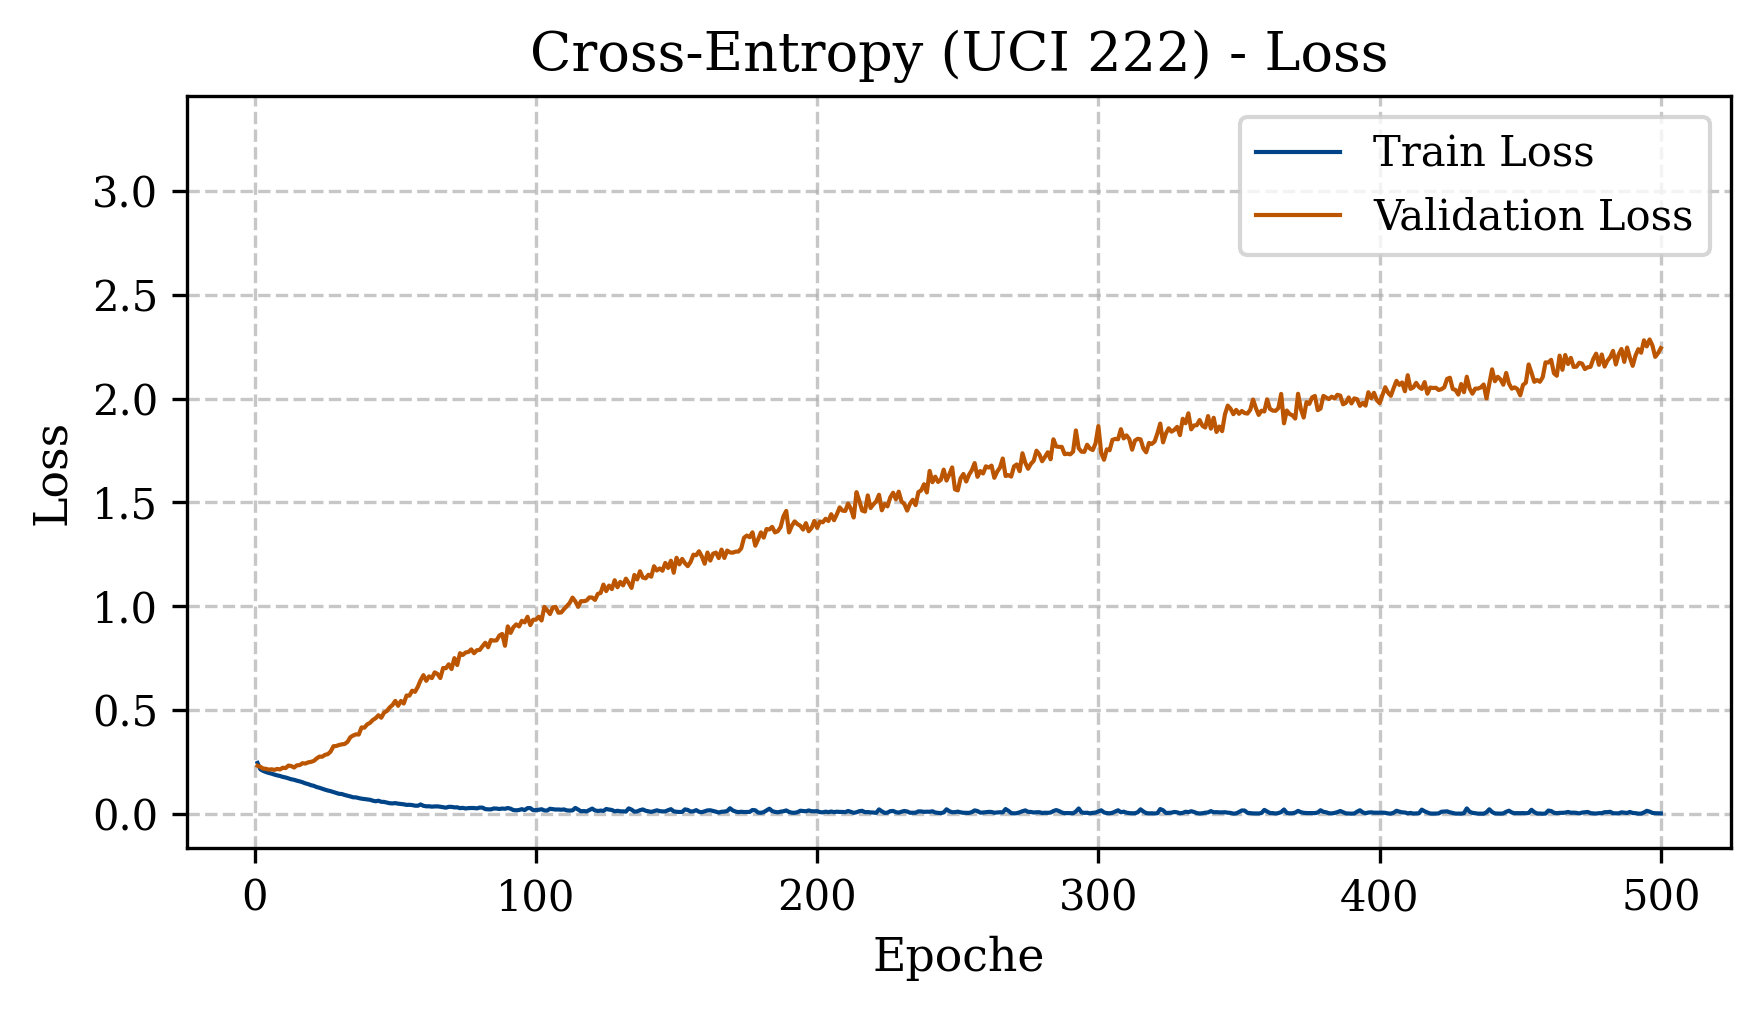

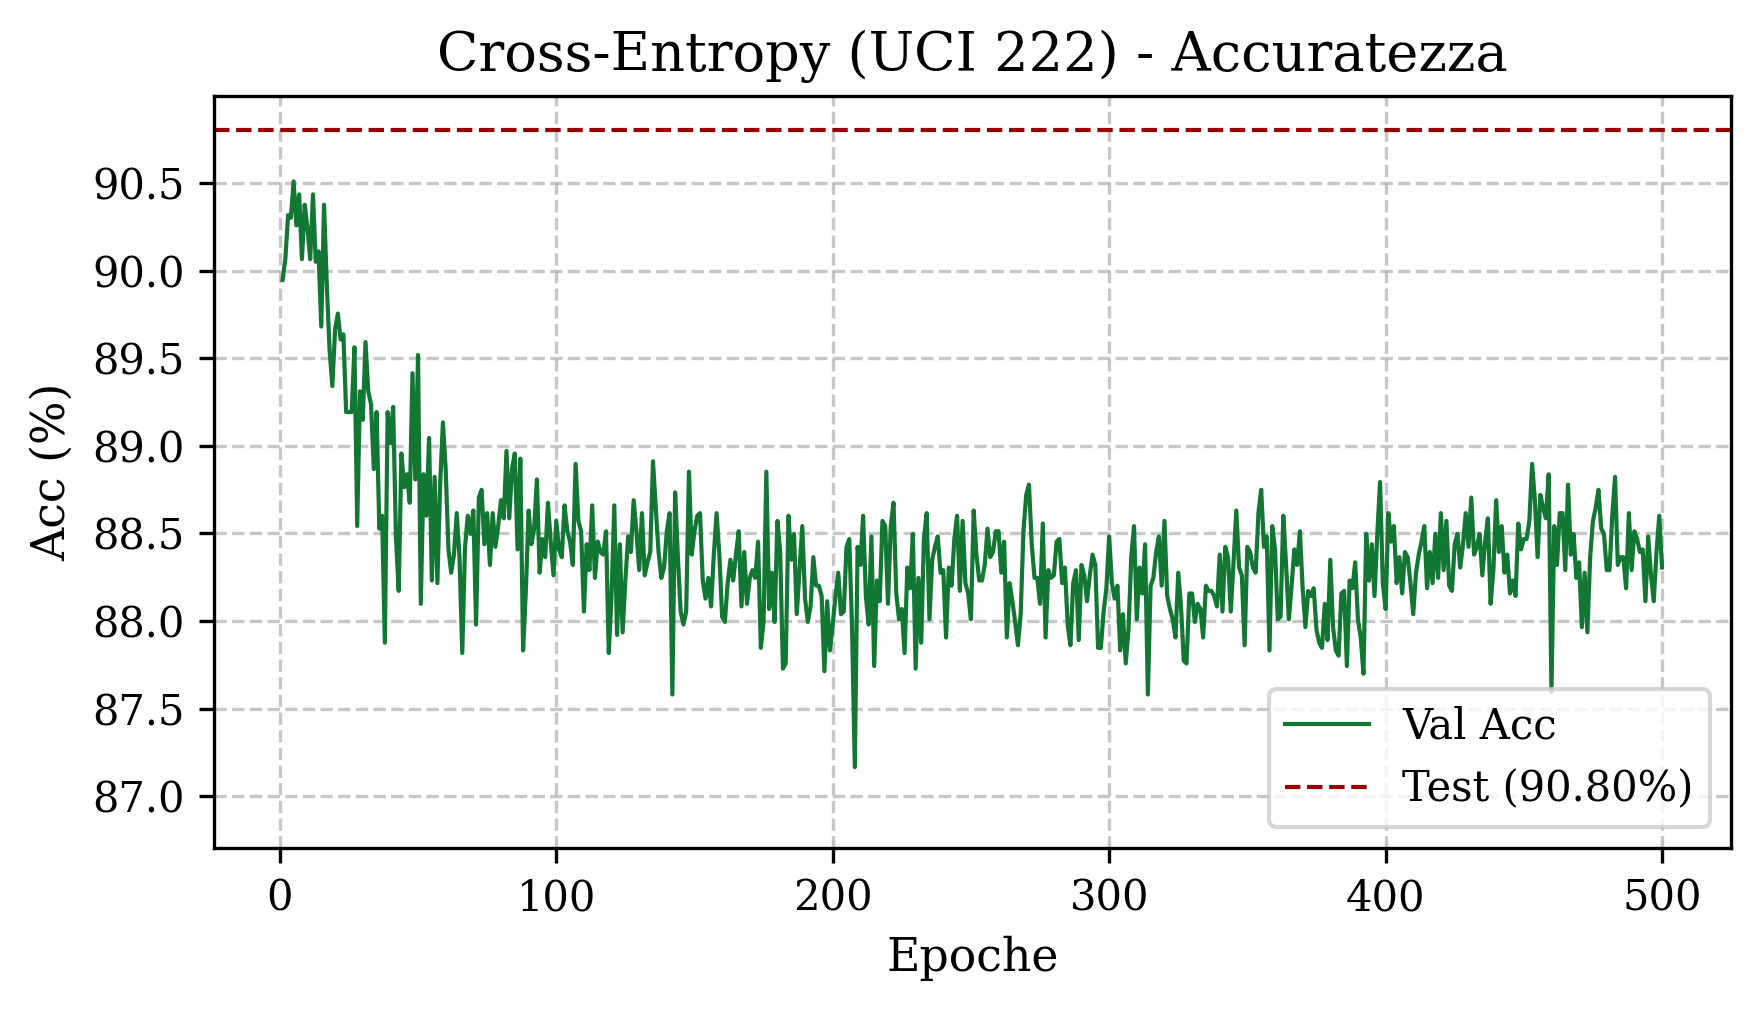

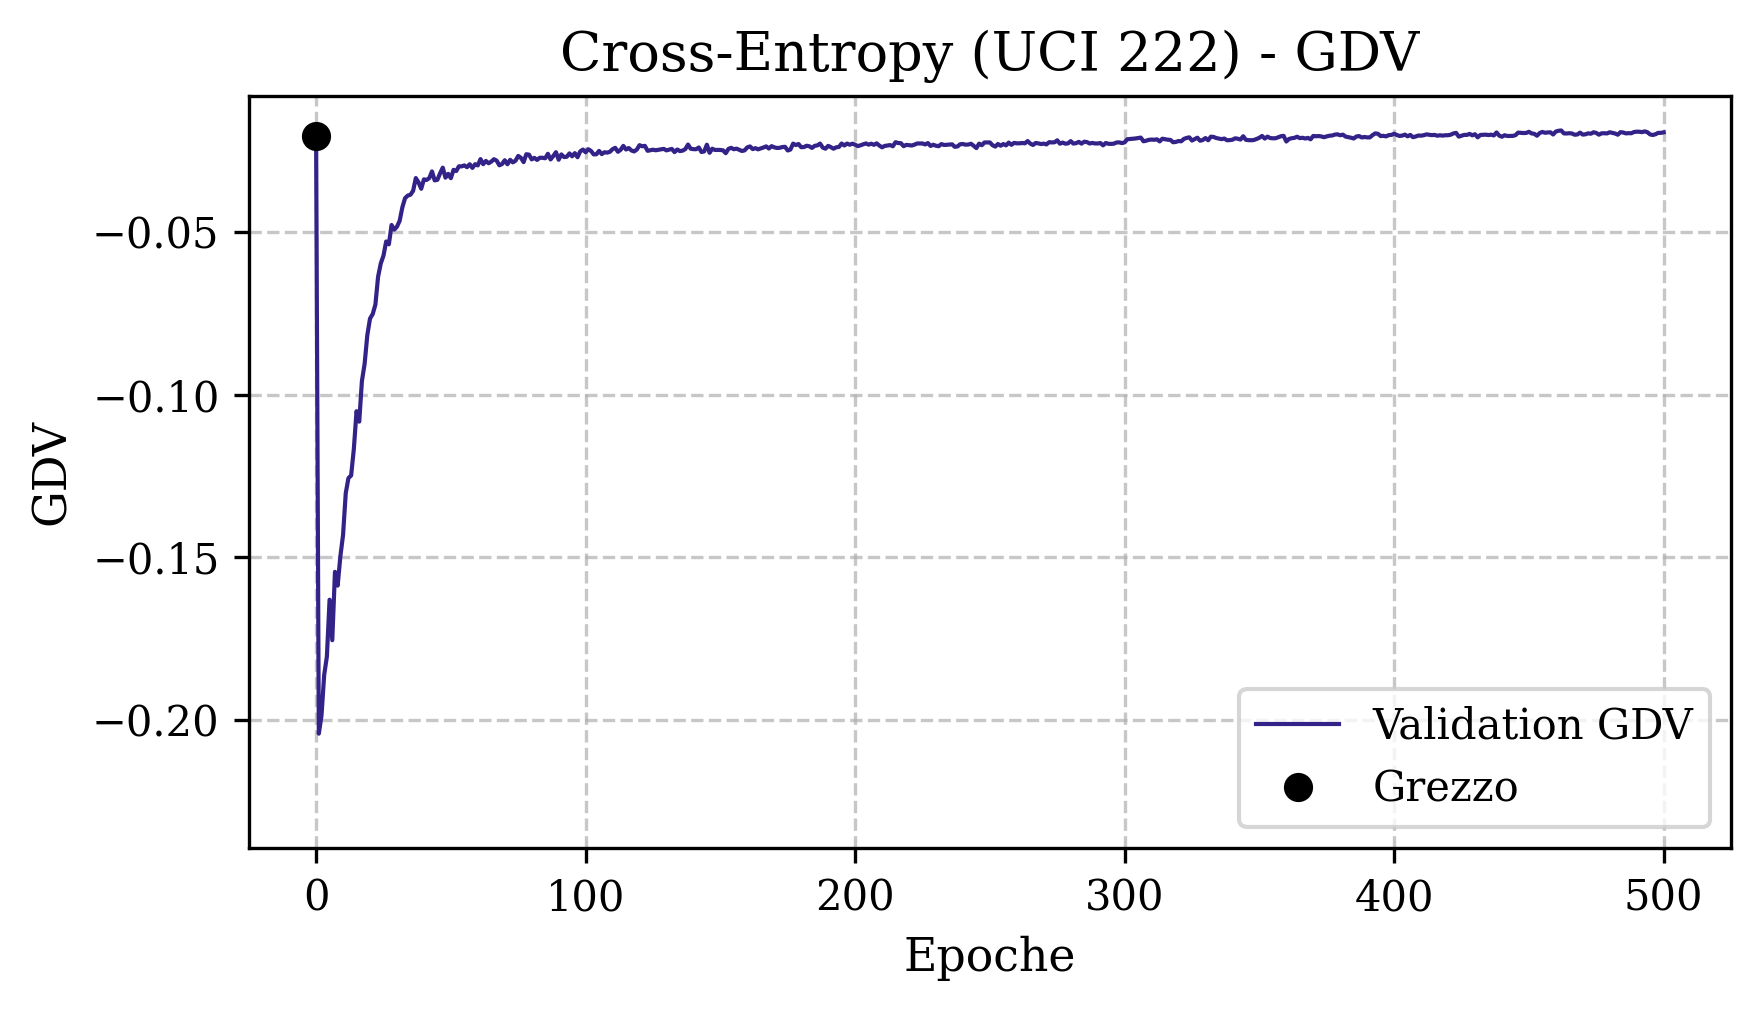

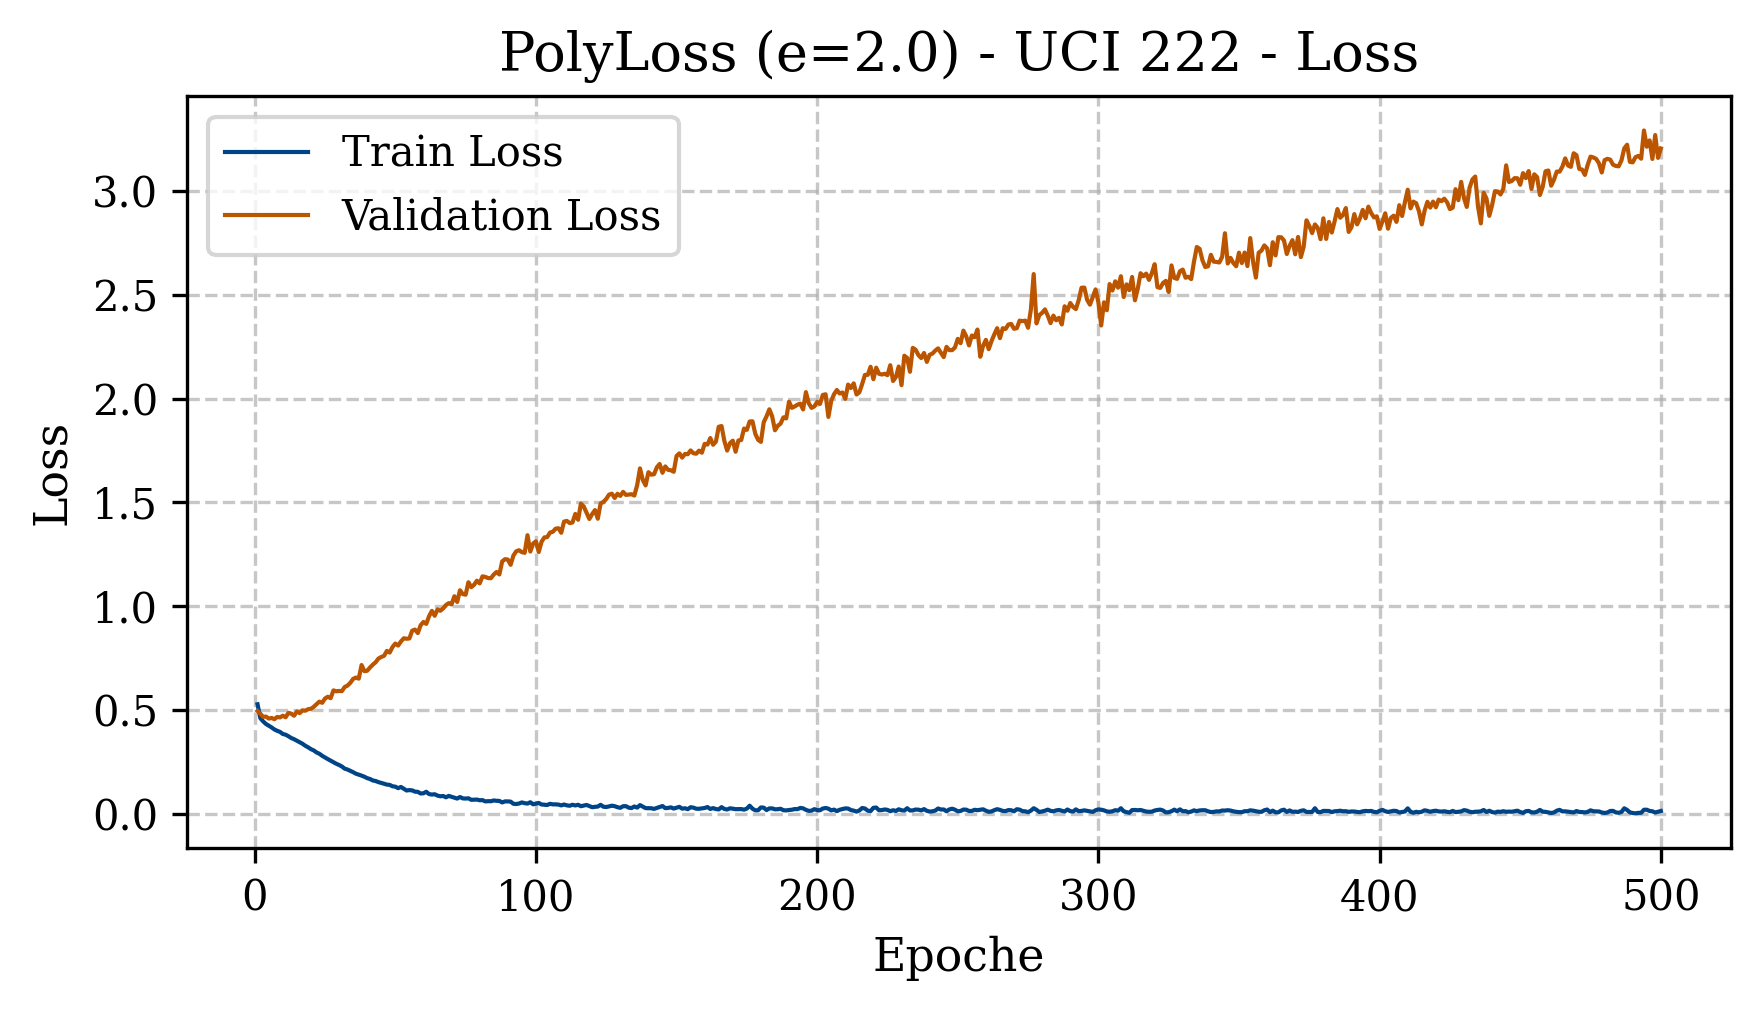

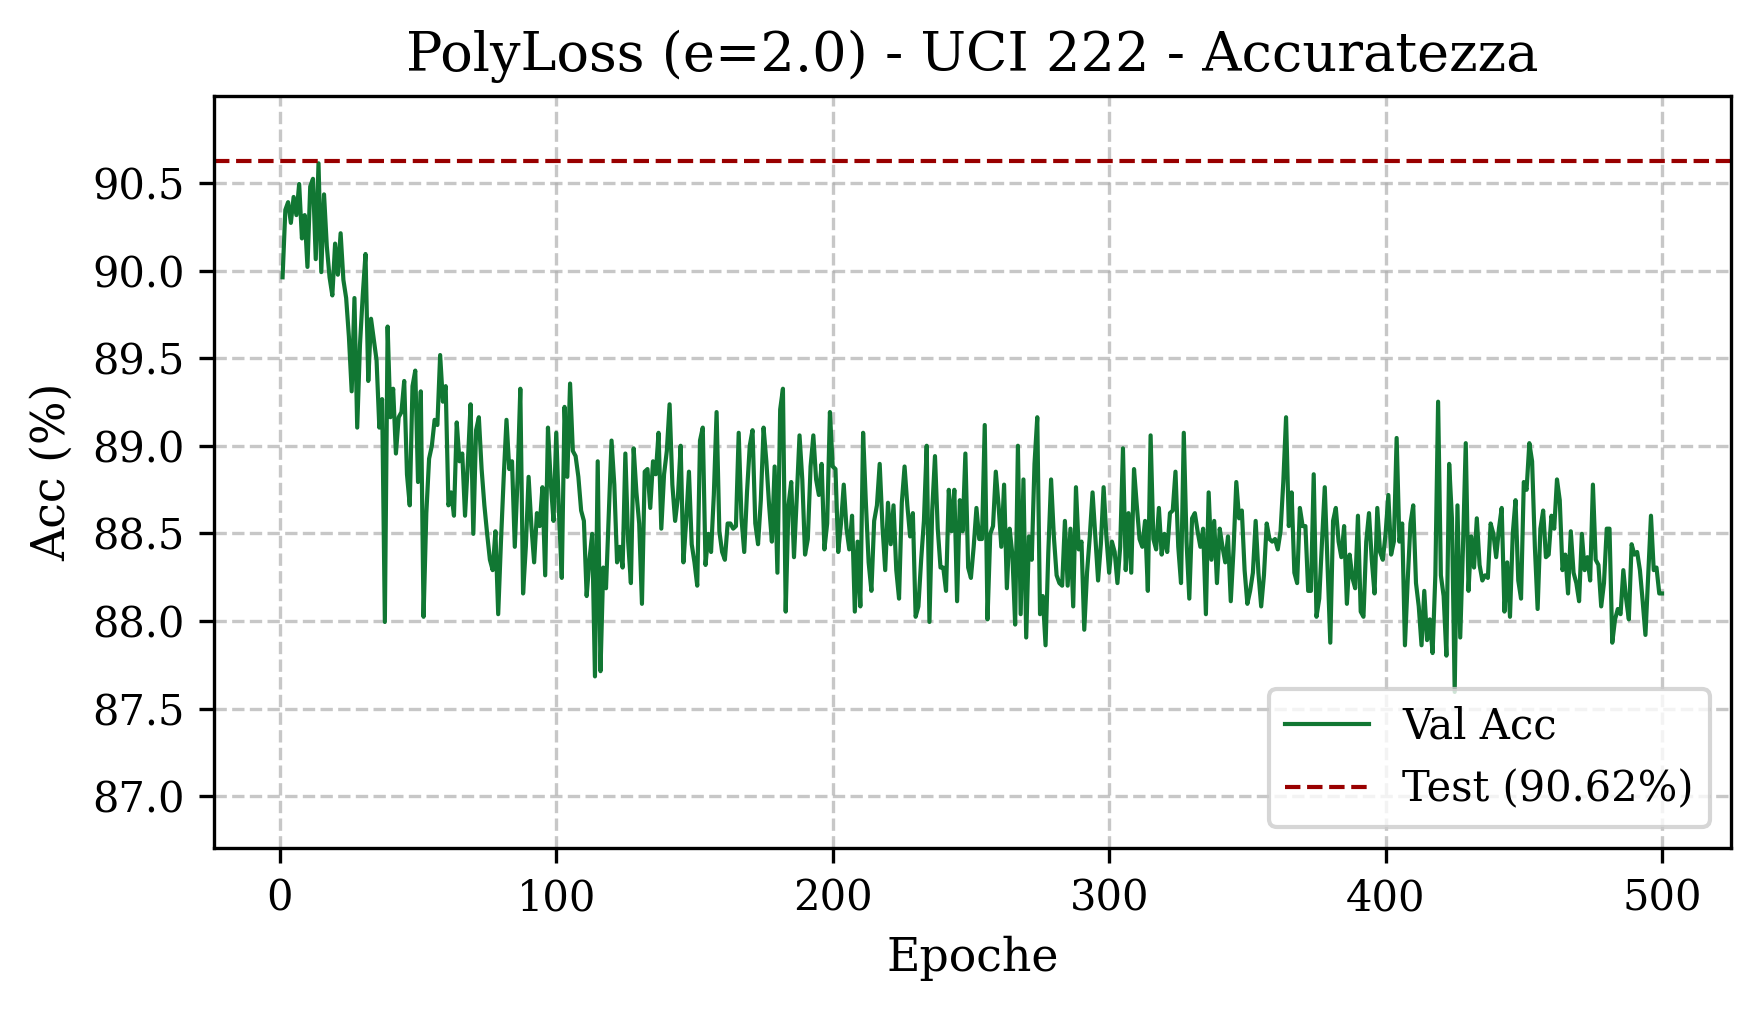

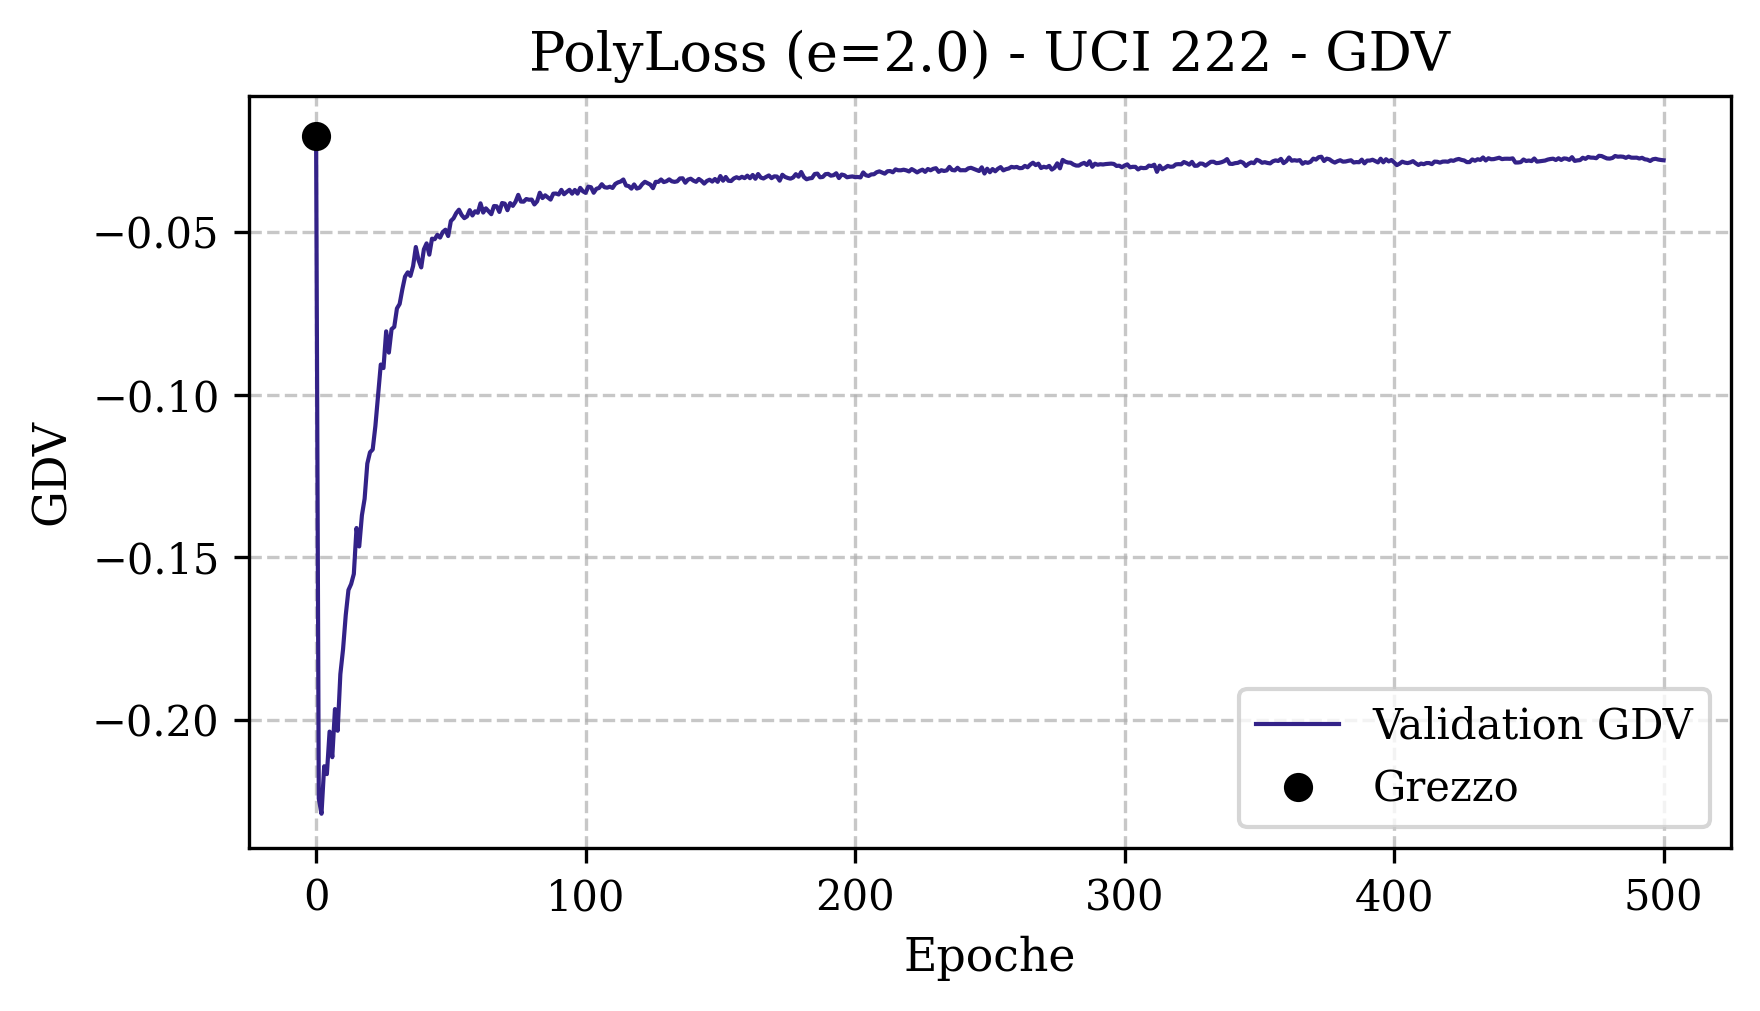

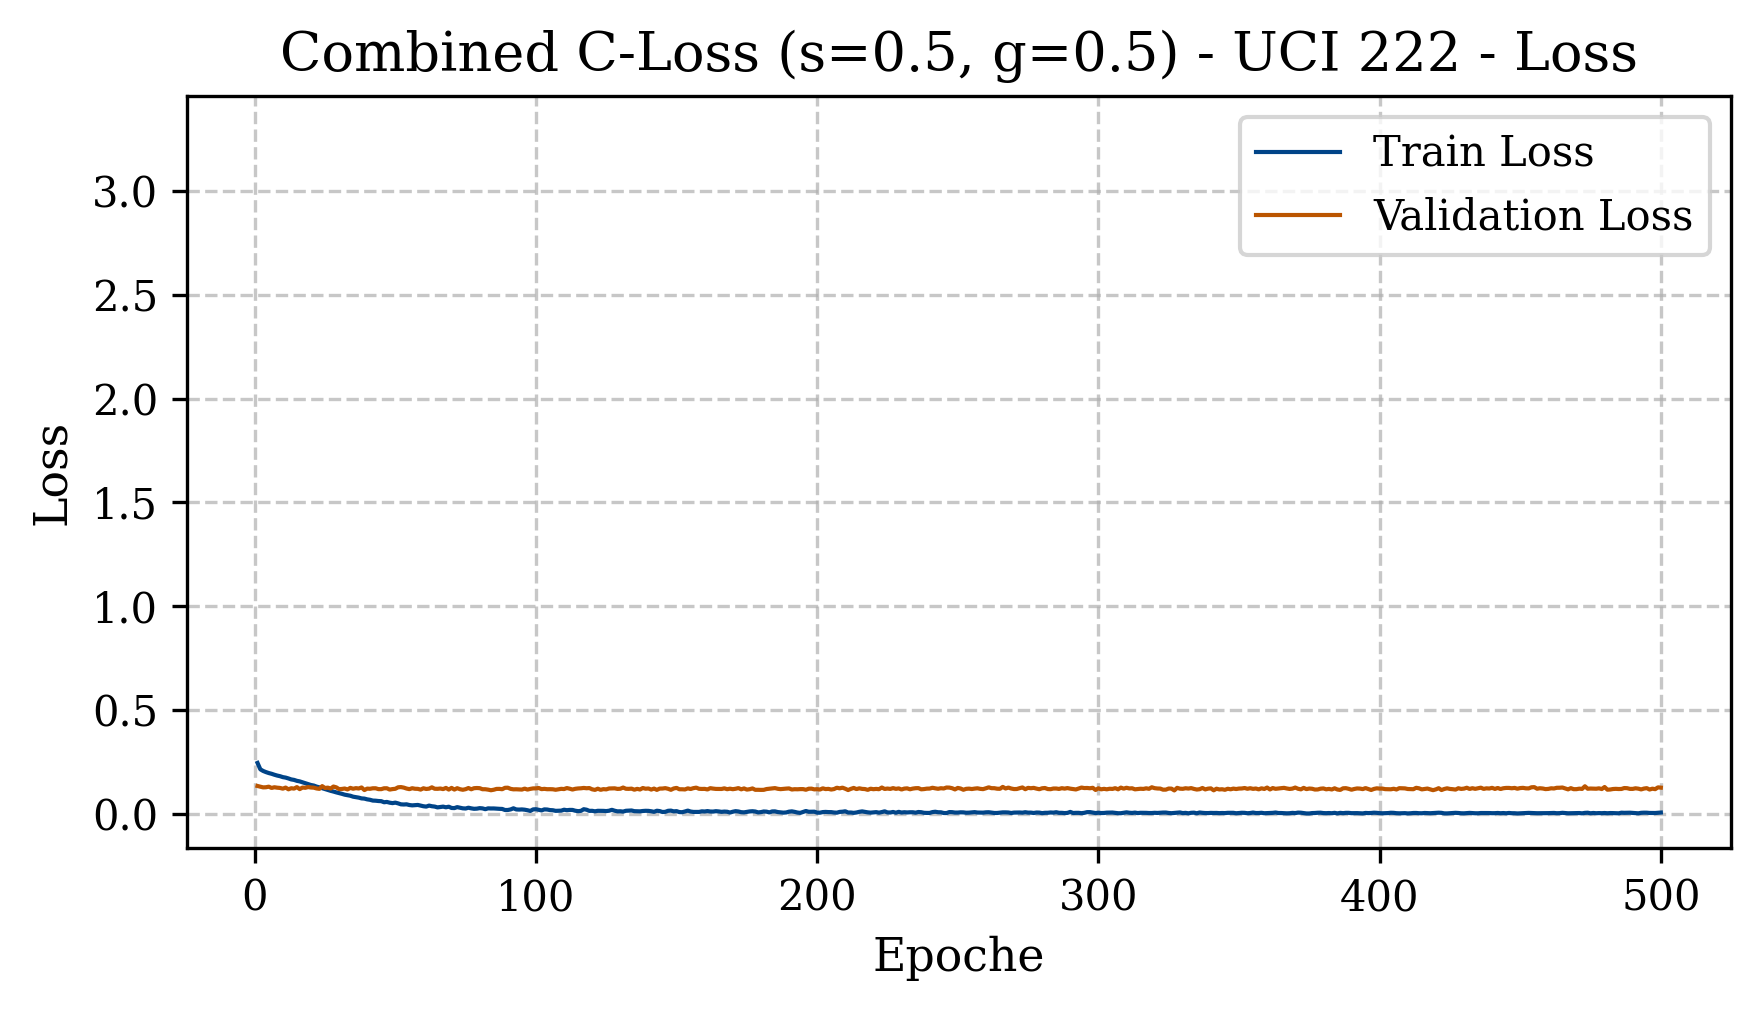

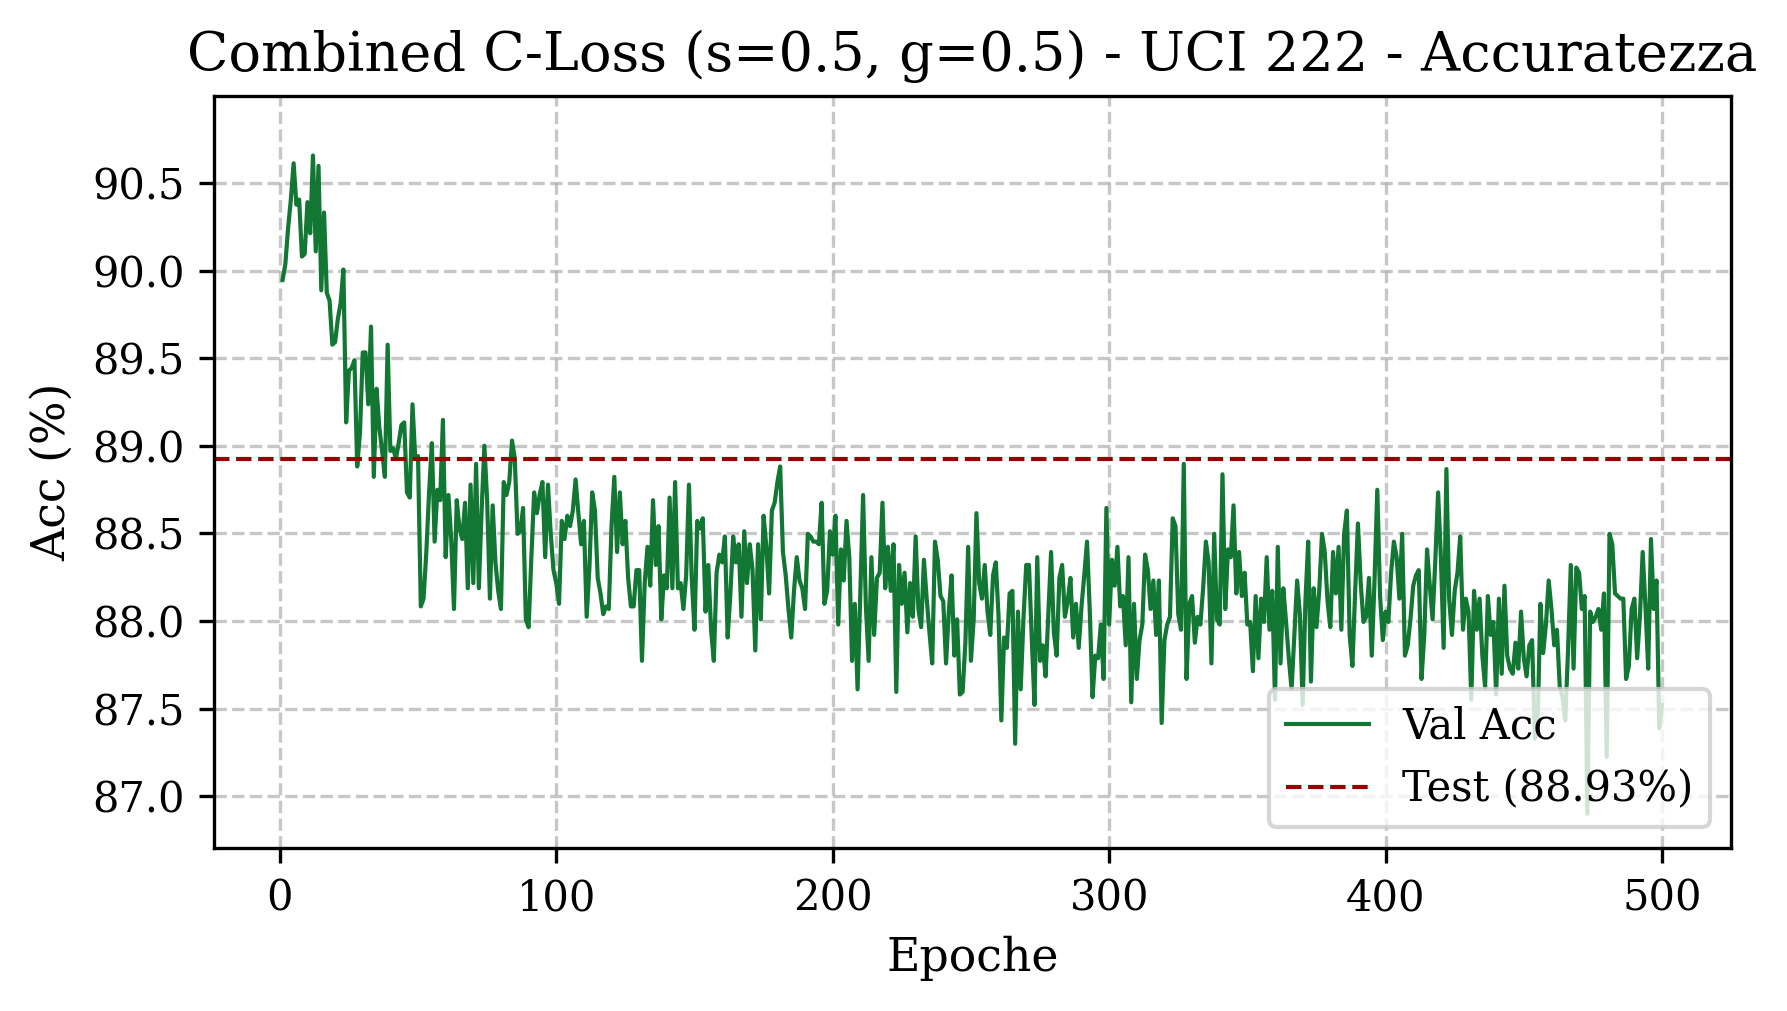

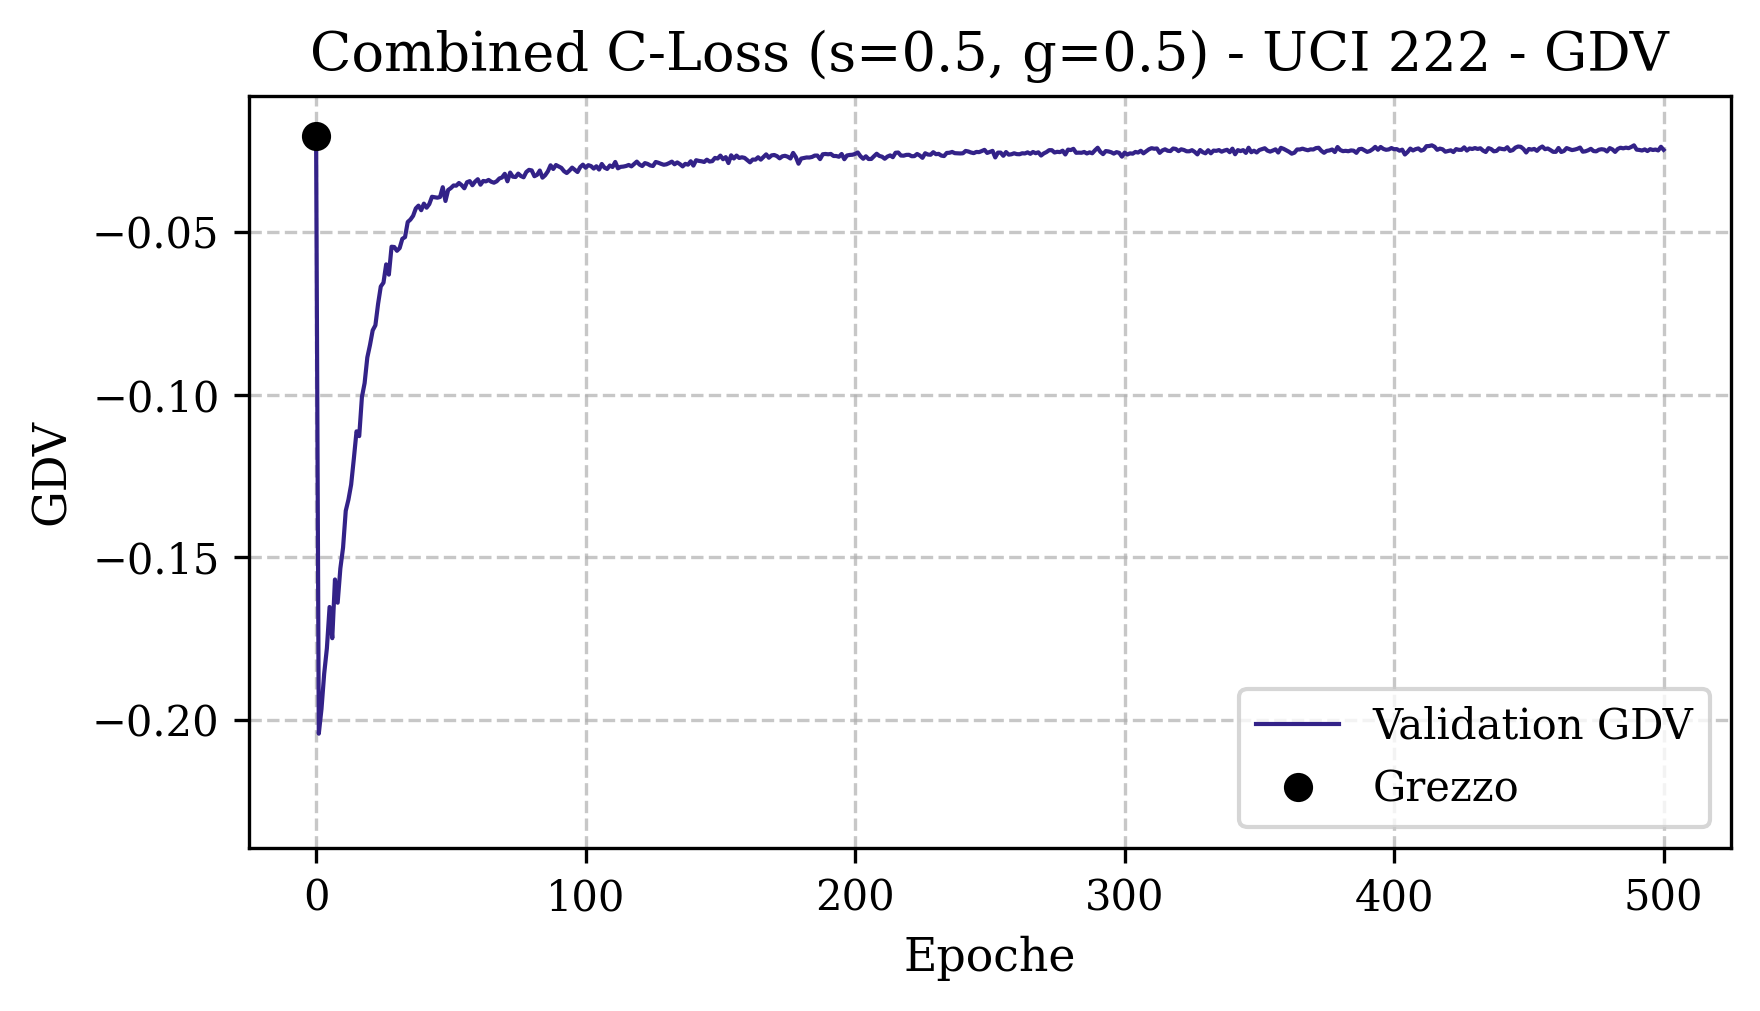

In [6]:
# === CELLA DI GENERAZIONE GRAFICI CON SCALA UNIFICATA ===
print(f"=== Generazione Grafici Comparativi per Dataset {dataset_id} ===")

def get_global_limits(histories, initial_gdv=None):
    all_losses = []
    all_accs = []
    all_gdvs = []
    
    if initial_gdv is not None:
        all_gdvs.append(initial_gdv)

    for h in histories:
        all_losses.extend(h['train_loss'])
        all_losses.extend(h['val_loss'])
        all_accs.extend(h['val_acc'])
        if 'test_acc' in h: all_accs.append(h['test_acc'])
        if 'val_gdv' in h: all_gdvs.extend(h['val_gdv'])

    # Calcolo limiti con piccolo margine (5%)
    def get_lim(data, margin=0.05):
        low, high = min(data), max(data)
        diff = high - low
        return (low - diff * margin, high + diff * margin)

    return {
        'loss': get_lim(all_losses),
        'acc': get_lim(all_accs),
        'gdv': get_lim(all_gdvs)
    }

# 1. Calcola i limiti basandosi sui tre storici
global_limits = get_global_limits([history_ce, history_poly, history_closs], initial_gdv=GDV_INIZIALE)

# 2. Genera i grafici usando la stessa scala per tutti
esperimenti = [
    (history_ce, f"Cross-Entropy (UCI {dataset_id})"),
    (history_poly, nome_poly_plot),
    (history_closs, nome_closs_plot)
]

for hist, name in esperimenti:
    plot_training_history(
        hist, 
        model_name=name, 
        gdv_iniziale=GDV_INIZIALE,
        dataset_id=dataset_id,
        y_limits=global_limits # <--- Qui passiamo la scala unificata
    )

In [ ]:
import random
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight # <--- NUOVO IMPORT
from dataset import create_dataloader, get_preprocessor
from models import MLP

# --- FUNZIONE SCUDO PER LA RIPRODUCIBILITÀ ---
def imposta_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# === ESPERIMENTO K-FOLD DINAMICO ===
# Nota: ora passiamo 'loss_factory' invece dell'istanza della loss
def run_kfold_experiment(loss_factory, model_name, X, y, n_classes, config):
    # Estrazione parametri specifici per il K-Fold dal config
    k_splits = config.get('kfold', {}).get('k_splits', 10)
    epochs_kfold = config.get('kfold', {}).get('epochs', 20)
    
    batch_size = config['dataset']['batch_size']
    base_seed = config['dataset'].get('random_state', 42)
    
    print(f"\n=== AVVIO {k_splits}-FOLD CV: {model_name} ===")
    print(f"Configurazione: {epochs_kfold} epoche per fold")
    
    imposta_seed(base_seed)
    skf = StratifiedKFold(n_splits=k_splits, shuffle=True, random_state=base_seed)
    
    fold_accs = []
    fold_gdvs = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n--- Fold {fold+1}/{k_splits} ---")
        
        seed_corrente = base_seed + fold
        imposta_seed(seed_corrente)
        
        # FIX PANDAS: Usiamo .iloc per fare lo slicing del DataFrame
        X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_va = y[train_idx], y[val_idx]
        
        # --- 1. CALCOLO PESI BILANCIATI (Anti-Sbilanciamento Dataset come il 572) ---
        # Usiamo np.arange(n_classes) per sicurezza, garantendo un peso per ogni classe teorica
        class_weights = compute_class_weight(
            class_weight='balanced',
            classes=np.arange(n_classes),
            y=y_tr
        )
        weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
        
        # --- 2. INIZIALIZZAZIONE DELLA LOSS DINAMICA ---
        # Creiamo la loss fresca per questo fold, iniettando il tensore dei pesi calcolato
        loss_fn = loss_factory(weights_tensor)
        
        # Preprocessing rigoroso: impara solo sul Train, applica al Validation
        preprocessor = get_preprocessor(X_tr)
        X_tr_proc = preprocessor.fit_transform(X_tr)
        X_va_proc = preprocessor.transform(X_va)
        
        # Estraiamo la dimensione esatta post-processing del fold corrente
        fold_in_dim = X_tr_proc.shape[1]
        
        # Creazione dataloader
        tr_loader = create_dataloader(X_tr_proc, y_tr, batch_size=batch_size, shuffle=True)
        va_loader = create_dataloader(X_va_proc, y_va, batch_size=batch_size, shuffle=False)
        
        model = MLP(
            input_size=fold_in_dim,
            num_classes=n_classes,
            hidden_layers=config['model']['hidden_layers'],
            dropout_rate=config['model']['dropout_rate']
        ).to(device)
        
        optimizer = optim.Adam(model.parameters(), lr=config['training']['learning_rate'])
        gdv_layer = model.get_layer_for_gdv(index=config['model']['gdv_layer_index'])
        
        # Addestramento con le epoche specifiche del K-Fold (Soft-Switch C-Loss e Early Stop sono nell'engine)
        history, best_ep = train_model(
            model=model, criterion=loss_fn, optimizer=optimizer,
            train_loader=tr_loader, val_loader=va_loader, device=device,
            num_epochs=epochs_kfold,
            layer_for_gdv=gdv_layer
        )
        
        # Valutazione
        acc = evaluate_model(model, va_loader, device)
        fold_accs.append(acc)
        
        best_gdv = history['val_gdv'][best_ep - 1] if history['val_gdv'] else 0.0
        fold_gdvs.append(best_gdv)
        
    return fold_accs, fold_gdvs

k_val = config.get('kfold', {}).get('k_splits', 10)
print(f"\n=== ESECUZIONE {k_val}-FOLD CV SU UCI ID {dataset_id} ===")

# 1. Estrazione dinamica degli iperparametri (gamma rimosso perché gestito dal Soft-Switch)
eps = config.get('loss_params', {}).get('polyloss', {}).get('epsilon', 2.0)
sig = config.get('loss_params', {}).get('closs', {}).get('sigma', 0.5)

# 2. Creazione nomi dinamici
nome_poly = f"PolyLoss (e={eps})"
nome_closs = f"C-Loss (s={sig})"

# 3. Esecuzione tramite LAMBDA FACTORY 
# Invece di creare l'oggetto loss qui, passiamo una funzione che lo creerà dentro il fold usando 'w' (i pesi)
acc_ce, gdv_ce = run_kfold_experiment(
    lambda w: nn.CrossEntropyLoss(weight=w), 
    "Cross-Entropy", X_raw, y_encoded, n_classes, config
)

acc_poly, gdv_poly = run_kfold_experiment(
    lambda w: PolyLoss(epsilon=eps, weight=w), 
    nome_poly, X_raw, y_encoded, n_classes, config
)

acc_closs, gdv_closs = run_kfold_experiment(
    lambda w: CombinedCLoss(sigma=sig, weight=w), 
    nome_closs, X_raw, y_encoded, n_classes, config
)

# Salvataggio MLOps
kfold_results = {
    "dataset_id": dataset_id,
    "folds": k_val,
    "Cross-Entropy": {"acc": acc_ce, "gdv": gdv_ce},
    nome_poly: {"acc": acc_poly, "gdv": gdv_poly},
    nome_closs: {"acc": acc_closs, "gdv": gdv_closs}
}

utils.salva_storico_json(    
    history=kfold_results,    
    nome_esperimento="KFold_Results", 
    dataset_id=dataset_id
)

print("\n" + "="*50)
print("--- RIEPILOGO FINALE K-FOLD (Accuratezza Media) ---")
print(f"1. Cross-Entropy: {np.mean(acc_ce):.2f}% (± {np.std(acc_ce):.2f}%)")
print(f"2. {nome_poly}: {np.mean(acc_poly):.2f}% (± {np.std(acc_poly):.2f}%)")
print(f"3. {nome_closs}: {np.mean(acc_closs):.2f}% (± {np.std(acc_closs):.2f}%)")


=== ESECUZIONE 10-FOLD CV SU UCI ID 222 ===

=== AVVIO 10-FOLD CV: Cross-Entropy ===
Configurazione: 200 epoche per fold

--- Fold 1/10 ---
Epoca 01/200 | Train Loss: 0.4022 | Val Loss: 0.3217 | Val Acc: 83.17% | Val GDV: -0.2516
Epoca 05/200 | Train Loss: 0.3258 | Val Loss: 0.3005 | Val Acc: 85.80% | Val GDV: -0.2317
Epoca 10/200 | Train Loss: 0.2960 | Val Loss: 0.2932 | Val Acc: 85.43% | Val GDV: -0.2010
Epoca 15/200 | Train Loss: 0.2693 | Val Loss: 0.3014 | Val Acc: 83.86% | Val GDV: -0.1581
Epoca 20/200 | Train Loss: 0.2386 | Val Loss: 0.3268 | Val Acc: 85.63% | Val GDV: -0.1166
Epoca 25/200 | Train Loss: 0.2112 | Val Loss: 0.3607 | Val Acc: 85.52% | Val GDV: -0.0806
Epoca 30/200 | Train Loss: 0.1844 | Val Loss: 0.4065 | Val Acc: 85.96% | Val GDV: -0.0593
Epoca 35/200 | Train Loss: 0.1595 | Val Loss: 0.5303 | Val Acc: 86.64% | Val GDV: -0.0495
Epoca 40/200 | Train Loss: 0.1405 | Val Loss: 0.5668 | Val Acc: 87.02% | Val GDV: -0.0441
Epoca 45/200 | Train Loss: 0.1237 | Val Loss: 0.6

In [ ]:
import os
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(5.5, 4.0))

modelli = ['Cross-Entropy', 'PolyLoss', 'Combined C-Loss']
medie_acc = [np.mean(acc_ce), np.mean(acc_poly), np.mean(acc_closs)]
std_acc = [np.std(acc_ce), np.std(acc_poly), np.std(acc_closs)]

colori = ['#004488', '#BB5500', '#117733']

barre = ax1.bar(modelli, medie_acc, yerr=std_acc, capsize=5, 
                color=colori, alpha=0.85, edgecolor='black', linewidth=1.0,
                error_kw={'elinewidth': 1.0, 'capthick': 1.0})

# ==========================================
# FIX: ASSI FISSI PER CONFRONTO GLOBALE
# ==========================================
y_min_fisso = 40.0  # Baseline fissa per avere proporzioni reali
y_max_fisso = 100.0

# Gestione eccezioni: se un dataset dovesse andare peggio del 40%, abbassiamo la visuale solo per lui
if min(medie_acc) < y_min_fisso:
    y_min_fisso = max(0.0, min(medie_acc) - 10.0)

ax1.set_ylim(y_min_fisso, y_max_fisso)

ax1.set_ylabel('Accuratezza Media (%)')
ax1.set_title(f'Confronto Prestazioni 10-Fold Cross Validation\n(Dataset UCI ID: {dataset_id})')

# Ricalcolo della centratura del testo rispetto al nuovo asse
for i, (barra, media) in enumerate(zip(barre, medie_acc)):
    altezza = barra.get_height()
    base_error_bar = altezza - std_acc[i]
    
    # Il testo si posiziona esattamente a metà tra il fondo del grafico e la sbarra d'errore
    y_text = y_min_fisso + (base_error_bar - y_min_fisso) / 2
    
    # Sicurezza per evitare che il testo "buchi" il fondo in casi estremi
    if y_text < y_min_fisso + 2:
        y_text = y_min_fisso + 5
    
    ax1.text(barra.get_x() + barra.get_width()/2., y_text, 
             f'{media:.2f}%', ha='center', va='center', 
             color='white', fontweight='bold', fontsize=10)

plt.grid(axis='y', linestyle='--')
plt.tight_layout()

# ==========================================
# SALVATAGGIO MLOPS
# ==========================================
base_dir = "results"
save_dir = os.path.join(base_dir, str(dataset_id), "plots")
os.makedirs(save_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
filename_pdf = os.path.join(save_dir, f"{timestamp}_KFold_Acc.pdf")

plt.savefig(filename_pdf, format='pdf', bbox_inches='tight')
print(f"[*] Grafico K-Fold salvato in: {filename_pdf}")

plt.show()